#  Análise Descritiva - Trabalho Estudantil
## Distribuições e Perfil Socioeconômico

**Notebook 3/7** - Série: Trabalho Estudantil e Desempenho no ENEM

---

##  Objetivos

1. Analisar a distribuição de estudantes por situação de trabalho
2. Calcular estatísticas descritivas de desempenho por grupo
3. Traçar o perfil socioeconômico dos estudantes que trabalham
4. Criar visualizações comparativas
5. Identificar padrões e tendências iniciais

---

## 1⃣ Setup e Carregamento de Dados

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuração
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print(" Bibliotecas carregadas")

 Bibliotecas carregadas


In [19]:
# Caminhos
PROJECT_ROOT = Path('/home/interas/faculdade/ciencia-dados/enem-data-exploration')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'enem_2023_trabalho_estudantil.parquet'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'unidade-3'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Paleta de cores
CORES_TRABALHO = {
    'Não trabalho': '#2E7D32',
    'Trabalho eventualmente': '#66BB6A',
    'Trabalho meio período': '#FFA726',
    'Trabalho período integral': '#EF5350'
}

CORES_CATEGORIA = {
    'Não trabalha': '#2E7D32',
    'Trabalho parcial': '#FFA726',
    'Período integral': '#EF5350'
}

print(f"Arquivo de dados: {DATA_FILE.exists()}")

Arquivo de dados: True


In [20]:
%%time
# Carregar dados
df = pd.read_parquet(DATA_FILE)

print(f"\n Dataset carregado:")
print(f"  Linhas: {len(df):,}")
print(f"  Colunas: {len(df.columns)}")
print(f"\n Pronto para análise!")


 Dataset carregado:
  Linhas: 1,000
  Colunas: 39

 Pronto para análise!
CPU times: user 20.2 ms, sys: 1.64 ms, total: 21.8 ms
Wall time: 12.4 ms


---

## 2⃣ Distribuição por Situação de Trabalho

In [21]:
# Contagem absoluta
dist_trabalho = df['Q007_label'].value_counts().sort_index()
print(" Distribuição por situação de trabalho:")
print(dist_trabalho)

# Percentuais
print("\n Percentuais:")
pct_trabalho = (dist_trabalho / len(df) * 100).round(2)
print(pct_trabalho)

 Distribuição por situação de trabalho:
Q007_label
Não trabalho                  10
Trabalho eventualmente        20
Trabalho meio período        931
Trabalho período integral     39
Name: count, dtype: int64

 Percentuais:
Q007_label
Não trabalho                  1.0
Trabalho eventualmente        2.0
Trabalho meio período        93.1
Trabalho período integral     3.9
Name: count, dtype: float64


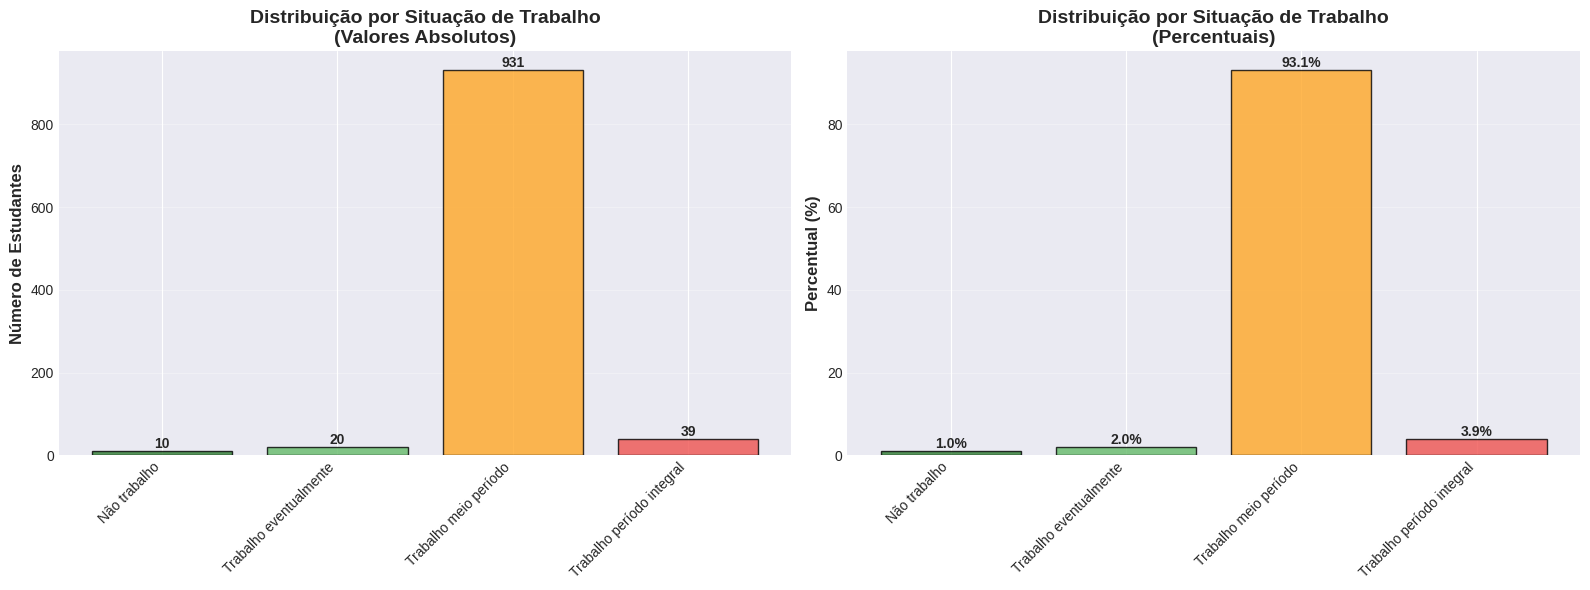

Gráfico salvo: 01_distribuicao_trabalho.png


In [22]:
# Visualização 1: Gráfico de barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absoluto
colors = [CORES_TRABALHO.get(x, '#888888') for x in dist_trabalho.index]
bars1 = ax1.bar(range(len(dist_trabalho)), dist_trabalho.values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xticks(range(len(dist_trabalho)))
ax1.set_xticklabels(dist_trabalho.index, rotation=45, ha='right')
ax1.set_ylabel('Número de Estudantes', fontsize=12, fontweight='bold')
ax1.set_title('Distribuição por Situação de Trabalho\n(Valores Absolutos)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Percentual
bars2 = ax2.bar(range(len(pct_trabalho)), pct_trabalho.values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(pct_trabalho)))
ax2.set_xticklabels(pct_trabalho.index, rotation=45, ha='right')
ax2.set_ylabel('Percentual (%)', fontsize=12, fontweight='bold')
ax2.set_title('Distribuição por Situação de Trabalho\n(Percentuais)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_distribuicao_trabalho.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo: 01_distribuicao_trabalho.png")

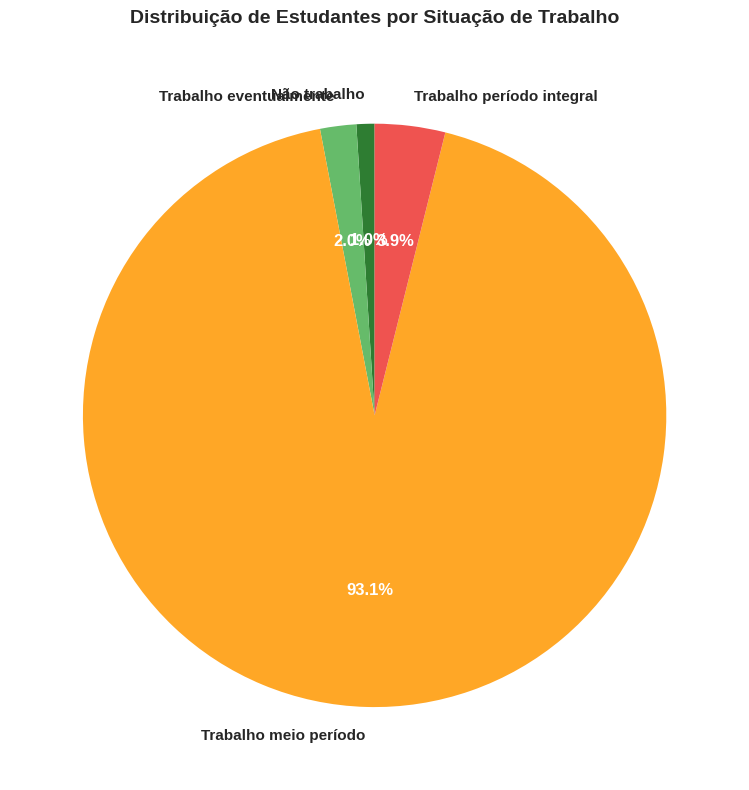

In [23]:
# Gráfico de pizza com matplotlib
fig, ax = plt.subplots(figsize=(10, 8))

colors = [CORES_TRABALHO.get(x, '#888888') for x in dist_trabalho.index]
wedges, texts, autotexts = ax.pie(
    dist_trabalho.values,
    labels=dist_trabalho.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Melhorar aparência dos textos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Distribuição de Estudantes por Situação de Trabalho', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01b_pizza_distribuicao.png', dpi=300, bbox_inches='tight')
plt.show()

###  Insights Preliminares

In [24]:
# Cálculos importantes
total = len(df)
trabalha = df['TRABALHA'].sum()
nao_trabalha = total - trabalha
pct_trabalha = (trabalha / total) * 100

periodo_integral = (df['Q007'] == 'D').sum()
pct_integral = (periodo_integral / total) * 100

print(" INSIGHTS:")
print("=" * 60)
print(f"\n1⃣ {pct_trabalha:.1f}% dos estudantes trabalham durante os estudos")
print(f"   → {trabalha:,} estudantes")
print(f"\n2⃣ {pct_integral:.1f}% trabalham período integral")
print(f"   → {periodo_integral:,} estudantes")
print(f"\n3⃣ {100-pct_trabalha:.1f}% não trabalham")
print(f"   → {nao_trabalha:,} estudantes")

 INSIGHTS:

1⃣ 99.0% dos estudantes trabalham durante os estudos
   → 990 estudantes

2⃣ 3.9% trabalham período integral
   → 39 estudantes

3⃣ 1.0% não trabalham
   → 10 estudantes


---

## 3⃣ Distribuição por Carga Horária

In [25]:
# Distribuição Q008
dist_carga = df['Q008_label'].value_counts().sort_index()
print(" Distribuição por carga horária:")
print(dist_carga)
print("\n Percentuais:")
print((dist_carga / len(df) * 100).round(2))

 Distribuição por carga horária:
Q008_label
11 a 20 horas    172
21 a 30 horas     28
31 a 40 horas      3
Até 10 horas     787
Nenhuma           10
Name: count, dtype: int64

 Percentuais:
Q008_label
11 a 20 horas    17.2
21 a 30 horas     2.8
31 a 40 horas     0.3
Até 10 horas     78.7
Nenhuma           1.0
Name: count, dtype: float64


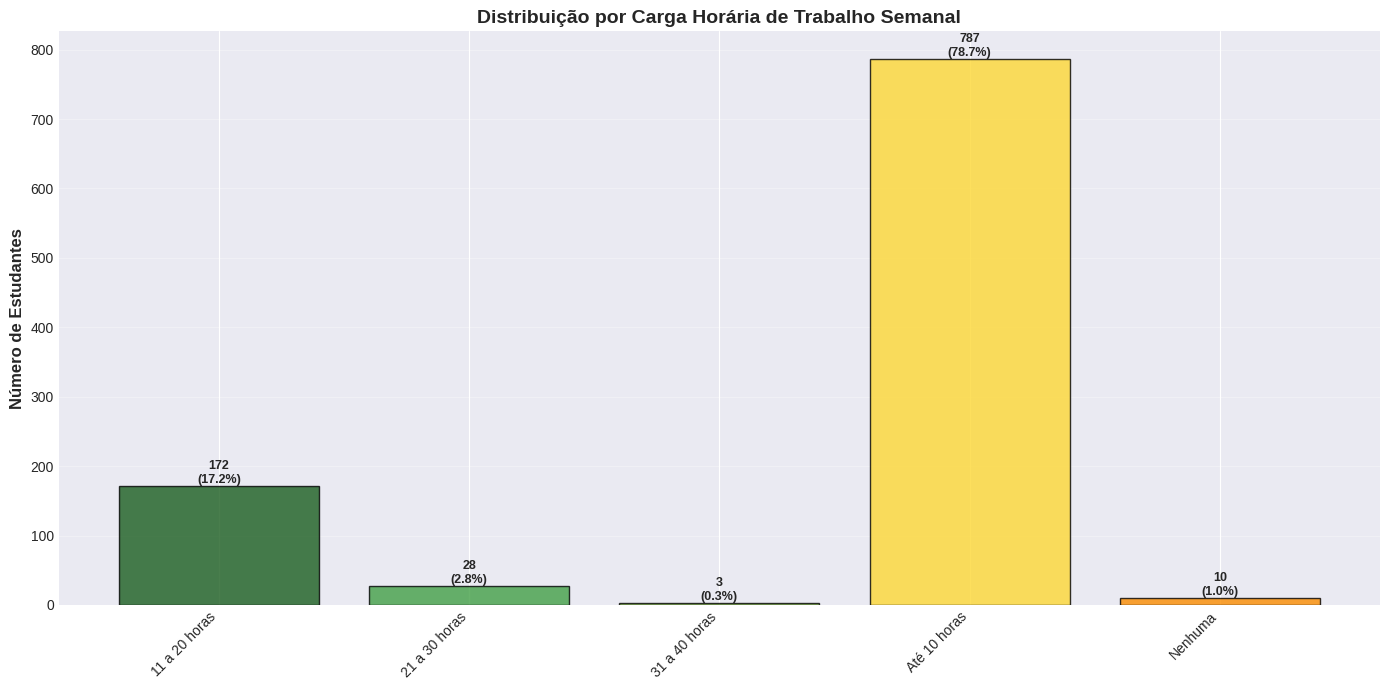

In [26]:
# Visualização: Carga horária
fig, ax = plt.subplots(figsize=(14, 7))

colors_carga = ['#1B5E20', '#43A047', '#7CB342', '#FDD835', '#FB8C00', '#E53935']
bars = ax.bar(range(len(dist_carga)), dist_carga.values, color=colors_carga, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(dist_carga)))
ax.set_xticklabels(dist_carga.index, rotation=45, ha='right')
ax.set_ylabel('Número de Estudantes', fontsize=12, fontweight='bold')
ax.set_title('Distribuição por Carga Horária de Trabalho Semanal', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Valores nas barras
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_distribuicao_carga_horaria.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 4⃣ Estatísticas de Desempenho por Grupo

In [27]:
# Estatísticas por situação de trabalho
print("ESTATÍSTICAS DE DESEMPENHO POR SITUAÇÃO DE TRABALHO")
print("=" * 80)

stats_trabalho = df.groupby('Q007_label')['NOTA_MEDIA_5'].agg([
    ('N', 'count'),
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')
]).round(2)

print(stats_trabalho)

# Salvar em CSV (criar diretório se não existir)
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
stats_trabalho.to_csv(PROCESSED_DIR / 'stats_trabalho.csv')
print("\nTabela salva: stats_trabalho.csv")

ESTATÍSTICAS DE DESEMPENHO POR SITUAÇÃO DE TRABALHO
                             N   Média  Mediana  Desvio Padrão  Mínimo  Máximo
Q007_label                                                                    
Não trabalho                10  529.27   492.15         120.00  379.66  757.06
Trabalho eventualmente      20  540.19   530.73          93.78  307.18  686.78
Trabalho meio período      931  539.62   537.04          97.85  243.32  799.54
Trabalho período integral   39  559.03   547.60          88.22  409.06  734.96

Tabela salva: stats_trabalho.csv


In [28]:
# Comparação: Trabalha vs Não Trabalha
print("\n COMPARAÇÃO: TRABALHA vs NÃO TRABALHA")
print("=" * 60)

stats_binario = df.groupby('TRABALHA')['NOTA_MEDIA_5'].agg([
    ('N', 'count'),
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std')
]).round(2)

stats_binario.index = ['Não trabalha', 'Trabalha']
print(stats_binario)

# Calcular gap
gap_absoluto = stats_binario.loc['Não trabalha', 'Média'] - stats_binario.loc['Trabalha', 'Média']
gap_percentual = (gap_absoluto / stats_binario.loc['Trabalha', 'Média']) * 100

print(f"\n GAP DE DESEMPENHO:")
print(f"   Absoluto: {gap_absoluto:.2f} pontos")
print(f"   Percentual: {gap_percentual:.2f}%")
print(f"\n   → Estudantes que NÃO trabalham têm {gap_absoluto:.1f} pontos a mais!")


 COMPARAÇÃO: TRABALHA vs NÃO TRABALHA
                N   Média  Mediana  Desvio Padrão
Não trabalha   10  529.27   492.15          120.0
Trabalha      990  540.40   537.11           97.4

 GAP DE DESEMPENHO:
   Absoluto: -11.13 pontos
   Percentual: -2.06%

   → Estudantes que NÃO trabalham têm -11.1 pontos a mais!


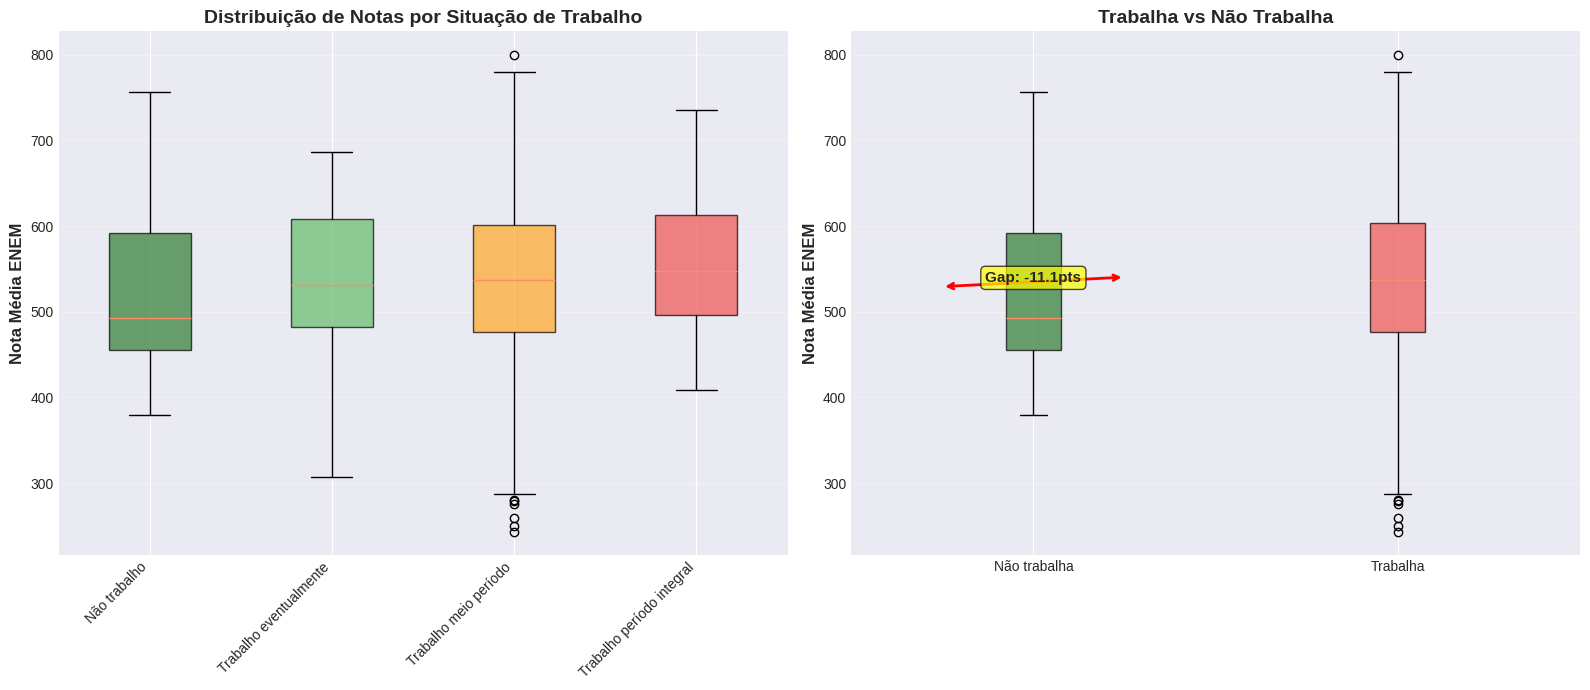

In [29]:
# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Por situação detalhada
data_trabalho = [df[df['Q007_label'] == cat]['NOTA_MEDIA_5'].dropna() 
                 for cat in dist_trabalho.index]
bp1 = axes[0].boxplot(data_trabalho, labels=dist_trabalho.index, patch_artist=True)

for patch, color in zip(bp1['boxes'], [CORES_TRABALHO.get(x, '#888') for x in dist_trabalho.index]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticklabels(dist_trabalho.index, rotation=45, ha='right')
axes[0].set_ylabel('Nota Média ENEM', fontsize=12, fontweight='bold')
axes[0].set_title('Distribuição de Notas por Situação de Trabalho', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Trabalha vs Não Trabalha
data_binario = [df[df['TRABALHA'] == i]['NOTA_MEDIA_5'].dropna() for i in [0, 1]]
bp2 = axes[1].boxplot(data_binario, labels=['Não trabalha', 'Trabalha'], patch_artist=True)

bp2['boxes'][0].set_facecolor('#2E7D32')
bp2['boxes'][1].set_facecolor('#EF5350')
for patch in bp2['boxes']:
    patch.set_alpha(0.7)

axes[1].set_ylabel('Nota Média ENEM', fontsize=12, fontweight='bold')
axes[1].set_title('Trabalha vs Não Trabalha', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Adicionar gap
y_max = axes[1].get_ylim()[1]
axes[1].annotate('', xy=(0.75, stats_binario.loc['Não trabalha', 'Média']),
                xytext=(1.25, stats_binario.loc['Trabalha', 'Média']),
                arrowprops=dict(arrowstyle='<->', lw=2, color='red'))
axes[1].text(1, (stats_binario.loc['Não trabalha', 'Média'] + stats_binario.loc['Trabalha', 'Média'])/2,
            f'Gap: {gap_absoluto:.1f}pts', ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_boxplot_desempenho.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 5⃣ Perfil Socioeconômico dos que Trabalham

 TRABALHO POR FAIXA DE RENDA
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
Q006_ord                                                            
1                           0.00              4.62             95.38
2                           1.34              2.68             95.99
3                           0.57              3.98             95.45
4                           0.00              3.88             96.12
5                           1.23              3.70             95.06
6                           0.00              0.00            100.00
7                           0.00              6.85             93.15
8                           0.00              0.00            100.00
9                           6.45              6.45             87.10
10                          0.00              4.35             95.65
11                         16.67             25.00             58.33
12                          0.00              0.00            100.00
13   

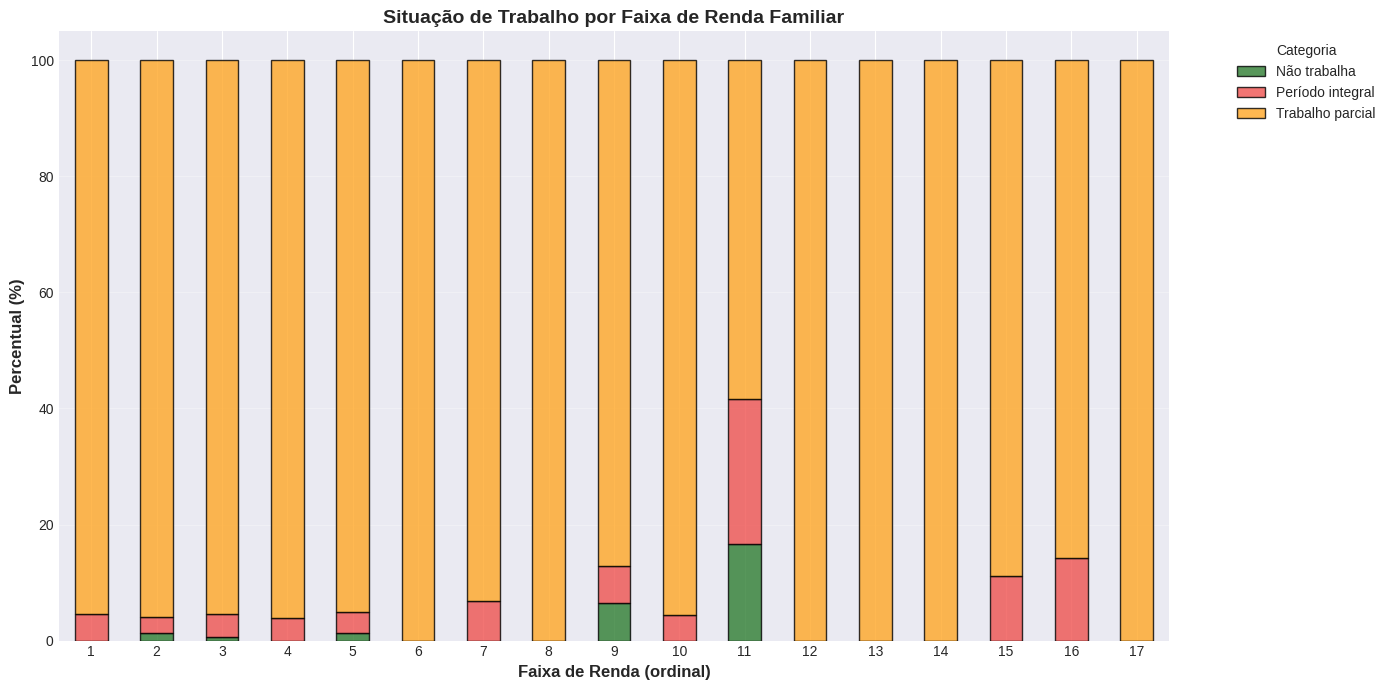

In [30]:
# Trabalho por Renda Familiar
if 'Q006_ord' in df.columns:
    print(" TRABALHO POR FAIXA DE RENDA")
    print("=" * 60)
    
    tabela_renda = pd.crosstab(
        df['Q006_ord'],
        df['CATEGORIA_TRABALHO'],
        normalize='index'
    ) * 100
    
    print(tabela_renda.round(2))
    
    # Visualizar
    tabela_renda.plot(kind='bar', stacked=True, figsize=(14, 7),
                     color=[CORES_CATEGORIA.get(x, '#888') for x in tabela_renda.columns],
                     alpha=0.8, edgecolor='black')
    plt.xlabel('Faixa de Renda (ordinal)', fontsize=12, fontweight='bold')
    plt.ylabel('Percentual (%)', fontsize=12, fontweight='bold')
    plt.title('Situação de Trabalho por Faixa de Renda Familiar', fontsize=14, fontweight='bold')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_trabalho_por_renda.png', dpi=300, bbox_inches='tight')
    plt.show()


 TRABALHO POR TIPO DE ESCOLA
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
ESCOLA_LABEL                                                        
Privada                     0.58              3.29             96.13
Pública                     1.61              3.76             94.62


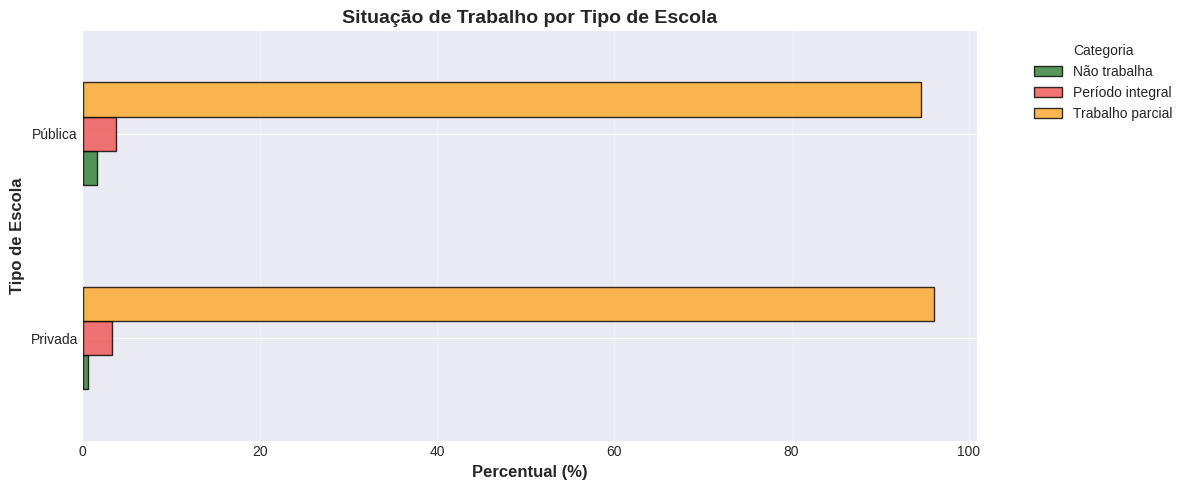

In [31]:
# Trabalho por Tipo de Escola
if 'TP_ESCOLA' in df.columns:
    print("\n TRABALHO POR TIPO DE ESCOLA")
    print("=" * 60)
    
    escola_map = {1: 'Privada', 2: 'Pública'}
    df['ESCOLA_LABEL'] = df['TP_ESCOLA'].map(escola_map)
    
    tabela_escola = pd.crosstab(
        df['ESCOLA_LABEL'],
        df['CATEGORIA_TRABALHO'],
        normalize='index'
    ) * 100
    
    print(tabela_escola.round(2))
    
    # Gráfico
    tabela_escola.plot(kind='barh', figsize=(12, 5),
                      color=[CORES_CATEGORIA.get(x, '#888') for x in tabela_escola.columns],
                      alpha=0.8, edgecolor='black')
    plt.xlabel('Percentual (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Tipo de Escola', fontsize=12, fontweight='bold')
    plt.title('Situação de Trabalho por Tipo de Escola', fontsize=14, fontweight='bold')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_trabalho_por_escola.png', dpi=300, bbox_inches='tight')
    plt.show()


 TRABALHO POR REGIÃO
CATEGORIA_TRABALHO  Não trabalha  Período integral  Trabalho parcial
REGIAO_NOME_PROVA                                                   
Centro-Oeste                1.33              2.67             96.00
Nordeste                    0.55              4.11             95.34
Norte                       1.67              2.50             95.83
Sudeste                     1.46              4.68             93.86
Sul                         0.00              3.06             96.94


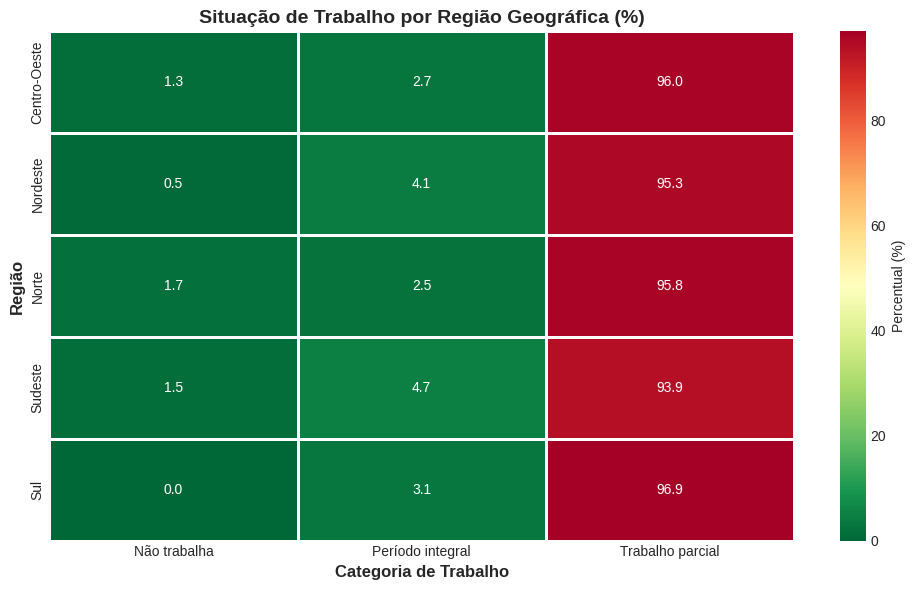

In [32]:
# Trabalho por Região
if 'REGIAO_NOME_PROVA' in df.columns:
    print("\n TRABALHO POR REGIÃO")
    print("=" * 60)
    
    tabela_regiao = pd.crosstab(
        df['REGIAO_NOME_PROVA'],
        df['CATEGORIA_TRABALHO'],
        normalize='index'
    ) * 100
    
    print(tabela_regiao.round(2))
    
    # Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(tabela_regiao, annot=True, fmt='.1f', cmap='RdYlGn_r',
                cbar_kws={'label': 'Percentual (%)'}, linewidths=1, linecolor='white')
    plt.title('Situação de Trabalho por Região Geográfica (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Categoria de Trabalho', fontsize=12, fontweight='bold')
    plt.ylabel('Região', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_trabalho_por_regiao.png', dpi=300, bbox_inches='tight')
    plt.show()

---

## 6⃣ Resumo Executivo

In [33]:
print("\n" + "="*80)
print(" " * 25 + "RESUMO EXECUTIVO")
print("="*80)

print(f"\n1⃣ PERFIL GERAL")
print(f"   • Total de estudantes: {len(df):,}")
print(f"   • Trabalham: {trabalha:,} ({pct_trabalha:.1f}%)")
print(f"   • Não trabalham: {nao_trabalha:,} ({100-pct_trabalha:.1f}%)")

print(f"\n2⃣ DESEMPENHO")
print(f"   • Média (não trabalha): {stats_binario.loc['Não trabalha', 'Média']:.2f}")
print(f"   • Média (trabalha): {stats_binario.loc['Trabalha', 'Média']:.2f}")
print(f"   • Gap: {gap_absoluto:.2f} pontos ({gap_percentual:.1f}%)")

if 'Q007_label' in df.columns:
    pior_grupo = stats_trabalho['Média'].idxmin()
    melhor_grupo = stats_trabalho['Média'].idxmax()
    print(f"\n3⃣ GRUPOS EXTREMOS")
    print(f"   • Melhor desempenho: {melhor_grupo} ({stats_trabalho.loc[melhor_grupo, 'Média']:.2f})")
    print(f"   • Pior desempenho: {pior_grupo} ({stats_trabalho.loc[pior_grupo, 'Média']:.2f})")
    print(f"   • Diferença: {stats_trabalho.loc[melhor_grupo, 'Média'] - stats_trabalho.loc[pior_grupo, 'Média']:.2f} pontos")

print("\n" + "="*80)


                         RESUMO EXECUTIVO

1⃣ PERFIL GERAL
   • Total de estudantes: 1,000
   • Trabalham: 990 (99.0%)
   • Não trabalham: 10 (1.0%)

2⃣ DESEMPENHO
   • Média (não trabalha): 529.27
   • Média (trabalha): 540.40
   • Gap: -11.13 pontos (-2.1%)

3⃣ GRUPOS EXTREMOS
   • Melhor desempenho: Trabalho período integral (559.03)
   • Pior desempenho: Não trabalho (529.27)
   • Diferença: 29.76 pontos



---

##  Conclusões Preliminares

### Principais Achados:

1. **Prevalência do Trabalho:** Uma parcela significativa dos estudantes trabalha durante os estudos
2. **Impacto no Desempenho:** Há diferença mensurável nas notas entre quem trabalha e quem não trabalha
3. **Gradiente de Trabalho:** Quanto maior a carga horária, menor tende a ser o desempenho
4. **Perfil Socioeconômico:** Trabalho está relacionado com renda, tipo de escola e região

###  Próximos Passos

 **`04_trabalho_vs_desempenho.ipynb`**

Onde iremos:
- Realizar testes estatísticos formais
- Calcular tamanho de efeito
- Analisar cada disciplina separadamente
- Investigar relações causais

---

*Análise realizada em: 10 de dezembro de 2025*